In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model21_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model21_0)
describe(model21_0)

MACs: 5.7 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─MaxPool2d: 3-8               [1, 30, 16, 16]           --
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 1

Loading checkpoint from model_weights/model21_0.pt
Starting
Epoch 1/60: Train loss = 1.0986, Train accuracy = 0.6102, Test loss = 1.0532, Test accuracy = 0.6259
Epoch 2/60: Train loss = 0.9749, Train accuracy = 0.6576, Test loss = 0.9753, Test accuracy = 0.6659
Epoch 3/60: Train loss = 0.8669, Train accuracy = 0.7031, Test loss = 0.8420, Test accuracy = 0.7080
Epoch 4/60: Train loss = 0.7894, Train accuracy = 0.7270, Test loss = 0.7969, Test accuracy = 0.7291
Epoch 5/60: Train loss = 0.6954, Train accuracy = 0.7567, Test loss = 0.7155, Test accuracy = 0.7527
Epoch 6/60: Train loss = 0.7116, Train accuracy = 0.7530, Test loss = 0.7456, Test accuracy = 0.7464
Epoch 7/60: Train loss = 0.6485, Train accuracy = 0.7766, Test loss = 0.6681, Test accuracy = 0.7703
Epoch 8/60: Train loss = 0.5885, Train accuracy = 0.7976, Test loss = 0.6257, Test accuracy = 0.7879
Epoch 9/60: Train loss = 0.5856, Train accuracy = 0.7978, Test loss = 0.6125, Test accuracy = 0.7887
Epoch 10/60: Train loss = 0.564

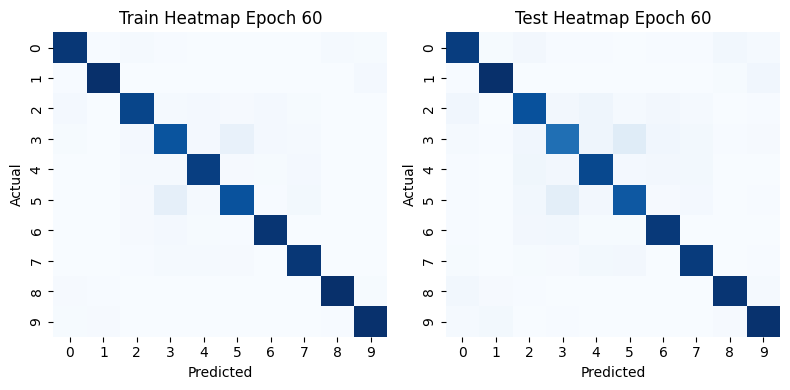

<Figure size 1200x600 with 0 Axes>

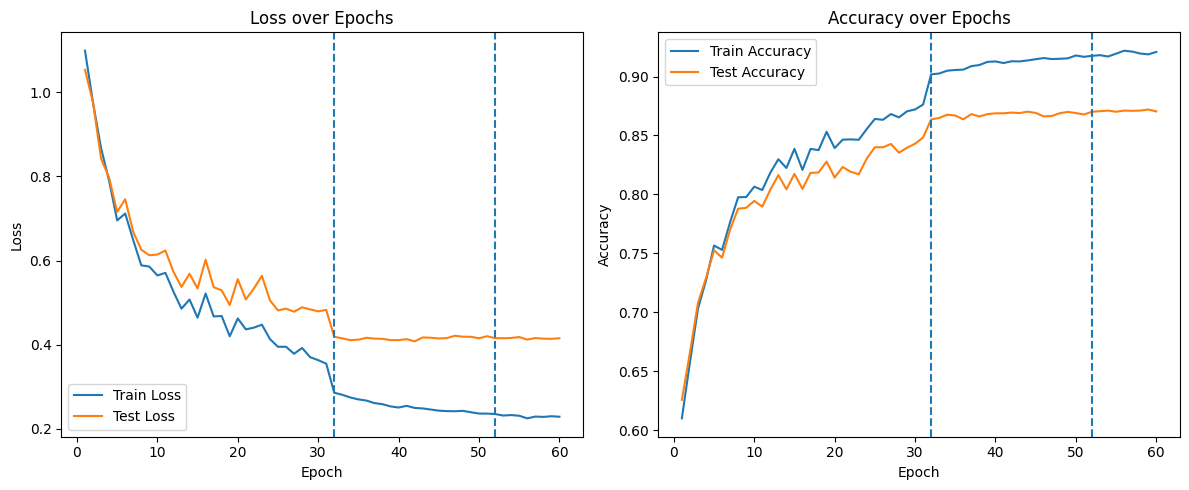

In [6]:
trainf32(model21_0,"model_weights/model21_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model21_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model21_1)
describe(model21_1)

MACs: 5.7 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─MaxPool2d: 3-8               [1, 30, 16, 16]           --
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 1

Loading checkpoint from model_weights/model21_1.pt
Starting
Epoch 1/60: Train loss = 1.0884, Train accuracy = 0.6108, Test loss = 1.0881, Test accuracy = 0.6128
Epoch 2/60: Train loss = 0.8929, Train accuracy = 0.6944, Test loss = 0.8808, Test accuracy = 0.7048
Epoch 3/60: Train loss = 0.7291, Train accuracy = 0.7487, Test loss = 0.7470, Test accuracy = 0.7434
Epoch 4/60: Train loss = 0.6840, Train accuracy = 0.7678, Test loss = 0.7086, Test accuracy = 0.7627
Epoch 5/60: Train loss = 0.6272, Train accuracy = 0.7814, Test loss = 0.6436, Test accuracy = 0.7816
Epoch 6/60: Train loss = 0.5945, Train accuracy = 0.7926, Test loss = 0.6177, Test accuracy = 0.7854
Epoch 7/60: Train loss = 0.5639, Train accuracy = 0.8060, Test loss = 0.5893, Test accuracy = 0.8022
Epoch 8/60: Train loss = 0.5349, Train accuracy = 0.8143, Test loss = 0.5685, Test accuracy = 0.8056
Epoch 9/60: Train loss = 0.5080, Train accuracy = 0.8236, Test loss = 0.5477, Test accuracy = 0.8122
Epoch 10/60: Train loss = 0.519

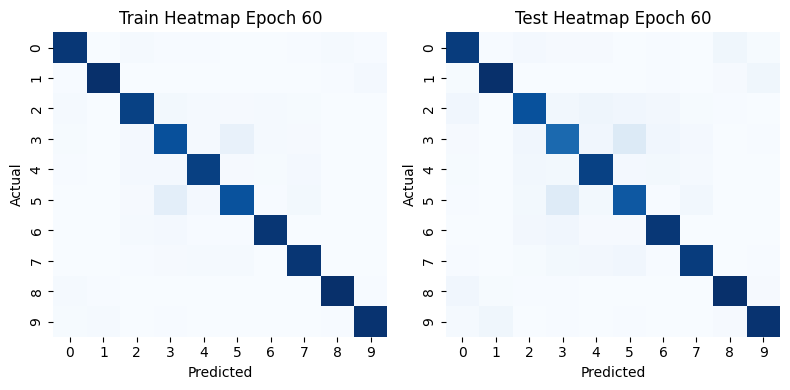

<Figure size 1200x600 with 0 Axes>

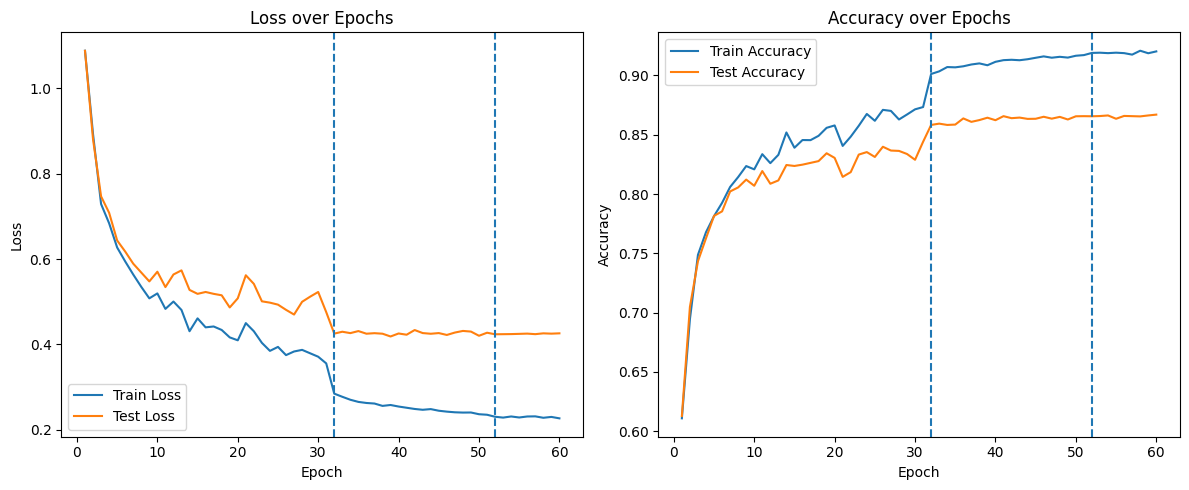

In [9]:
trainf32(model21_1,"model_weights/model21_1.pt",criterion,train_dataset,val_dataset, batch_size=64)